In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import bayesflow as bf

import sys
sys.path.append("../")

from src.generative_models import *
from src.priors import pt_prior

np.set_printoptions(suppress=True)

/Users/lschumacher/miniconda3/envs/beef/lib/python3.11/site-packages/bayesflow/trainers.py:27: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
data = pd.read_csv("../data/pilot_data_prepped.csv")
NUM_SUBJECTS = len(data.id.unique())
SUBJECTS = data.id.unique()
NUM_OBS = 100
NUM_SAMPLES = 1000

In [55]:
import matplotlib
matplotlib.rcParams['font.serif'] = "Palatino"
matplotlib.rcParams['font.family'] = "serif"

FONTSIZE_1 = 32
FONTSIZE_2 = 22

In [3]:
emp_data = np.zeros((NUM_SUBJECTS, 2, NUM_OBS, 7))
for i, subject in enumerate(SUBJECTS):
    subject_data_old = data[(data.id == subject) & (data.condition == "old")]
    subject_data_new = data[(data.id == subject) & (data.condition == "new")]
    
    resp_old = subject_data_old.resp.to_numpy()[:, None]
    resp_new = subject_data_new.resp.to_numpy()[:, None]

    context_old = subject_data_old.iloc[:, 8:14].to_numpy() / 50
    context_new = subject_data_new.iloc[:, 8:14].to_numpy() / 50
    emp_data[i, 0] = np.c_[resp_old, context_old]
    emp_data[i, 1] = np.c_[resp_new, context_new]

## Model Fitting

In [4]:
summary_net = bf.networks.SetTransformer(input_dim=7, summary_dim=32)

inference_net = bf.networks.InvertibleNetwork(
    num_params=len(pt_prior.param_names),
    coupling_settings={"dense_args": dict(kernel_regularizer=None), "dropout": False},
)

In [5]:
pt_amortizer = bf.amortizers.AmortizedPosterior(inference_net, summary_net)

pt_trainer = bf.trainers.Trainer(
    generative_model=pt_model, 
    amortizer=pt_amortizer, 
    configurator=pt_configurator, 
    checkpoint_path=f"../checkpoints/pt_model_final",
    max_to_keep=1
)

INFO:root:Loaded loss history from ../checkpoints/pt_model_final/history_100.pkl.
INFO:root:Networks loaded from ../checkpoints/pt_model_final/ckpt-100
INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


In [6]:
pt_post_z = np.zeros((NUM_SUBJECTS, 2, NUM_SAMPLES, 3))

In [7]:
pt_post_z[:, 0] = pt_amortizer.sample(
    {"summary_conditions": emp_data[:, 0].astype(np.float32)},
    NUM_SAMPLES
)
pt_post_z[:, 1] = pt_amortizer.sample(
    {"summary_conditions": emp_data[:, 1].astype(np.float32)},
    NUM_SAMPLES
)

In [8]:
pt_post = pt_post_z * PT_PRIOR_STD + PT_PRIOR_MEAN

In [24]:
pt_post_median = np.median(pt_post, axis=2)
pt_post_median.mean(axis=0)

array([[1.87382368, 0.77558138, 0.3417115 ],
       [1.61450009, 0.57991766, 0.96286873]])

In [10]:
pt_post.shape

(12, 2, 1000, 3)

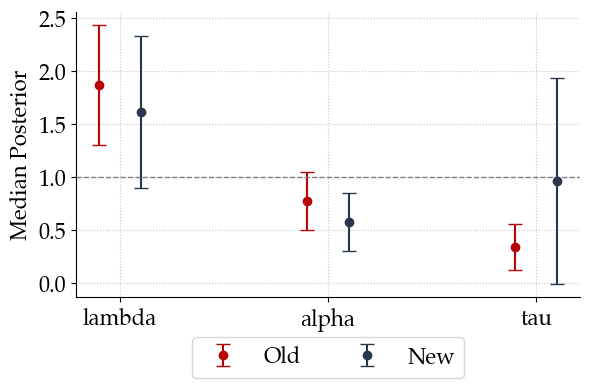

In [61]:
FONTSIZE_2 = 16

import matplotlib.pyplot as plt
import numpy as np

# Setup
param_names = ['lambda', 'alpha', 'tau']
n_subjects, n_conditions, n_samples, n_params = pt_post.shape
colors = ['#B70404', '#27374D']  # Old, New
condition_labels = ['Old', 'New']

# Compute subject-wise medians, then group mean and std
subject_medians = np.median(pt_post, axis=2)  # shape: (12, 2, 3)
mean_medians = subject_medians.mean(axis=0)   # shape: (2, 3)
std_medians = subject_medians.std(axis=0)     # shape: (2, 3)

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(n_params)
width = 0.2  # dodge

for c in range(n_conditions):
    x_offset = x - width/2 + c*width
    y = mean_medians[c]
    yerr = std_medians[c]
    ax.errorbar(x_offset, y, yerr=yerr, fmt='o', color=colors[c], capsize=5,
                label=condition_labels[c], markersize=6)

# Reference line at y=1
ax.axhline(1, color='gray', linestyle='--', linewidth=1)

# Grid
ax.grid(True, which='both', linestyle=':', linewidth=0.8, alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(param_names)
ax.legend()
ax.set_xticklabels(param_names, fontsize=FONTSIZE_2)
ax.set_ylabel('Median Posterior', fontsize=FONTSIZE_2)
ax.tick_params(axis='y', labelsize=FONTSIZE_2)
ax.tick_params(axis='x', labelsize=FONTSIZE_2)

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, fontsize=FONTSIZE_2)
plt.tight_layout()
sns.despine()
plt.savefig("../plots/pt_estimates.pdf", bbox_inches='tight', dpi=300) 

In [9]:
pt_post_median = np.mean(pt_post, axis=2)

In [75]:
pt_post_median_mean = np.mean(pt_post_median, axis=0)
pt_post_median_std = np.std(pt_post_median, axis=0)
pt_post_median_mean

array([[1.88137069, 0.80019603, 0.45482955],
       [1.6176872 , 0.59063731, 1.18064853]])

## Alternative

In [41]:
summary_net = bf.networks.SetTransformer(input_dim=7, summary_dim=32)

inference_net = bf.networks.InvertibleNetwork(
    num_params=4,
    coupling_settings={"dense_args": dict(kernel_regularizer=None), "dropout": False},
)

In [42]:
cpt_amortizer = bf.amortizers.AmortizedPosterior(inference_net, summary_net)

cpt_trainer = bf.trainers.Trainer(
    generative_model=cpt_model, 
    amortizer=cpt_amortizer, 
    configurator=cpt_configurator, 
    checkpoint_path=f"../checkpoints/{cpt_model.name}",
    max_to_keep=1
)

INFO:root:Loaded loss history from ../checkpoints/cpt_model/history_100.pkl.
INFO:root:Networks loaded from ../checkpoints/cpt_model/ckpt-100
INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


In [39]:
cpt_post_z = np.zeros((NUM_SUBJECTS, 2, NUM_SAMPLES, 4))

In [43]:
cpt_post_z[:, 0] = cpt_amortizer.sample(
    {"summary_conditions": emp_data[:, 0].astype(np.float32)},
    NUM_SAMPLES
)
cpt_post_z[:, 1] = cpt_amortizer.sample(
    {"summary_conditions": emp_data[:, 1].astype(np.float32)},
    NUM_SAMPLES
)

In [44]:
cpt_post = cpt_post_z * CPT_PRIOR_STD + CPT_PRIOR_MEAN

In [45]:
cpt_post_median = np.median(cpt_post, axis=2)
cpt_post_median.mean(axis=0)

array([[1.86759617, 0.83283725, 0.87138442, 0.32799083],
       [1.37938175, 0.52845475, 0.87170969, 0.89277422]])

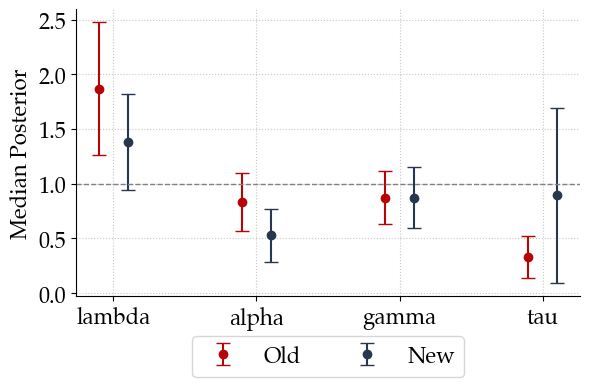

In [62]:
param_names = ['lambda', 'alpha', 'gamma', 'tau']
n_subjects, n_conditions, n_samples, n_params = cpt_post.shape
colors = ['#B70404', '#27374D']  # Old, New
condition_labels = ['Old', 'New']

# Compute subject-wise medians, then group mean and std
subject_medians = np.median(cpt_post, axis=2)  # shape: (12, 2, 3)
mean_medians = subject_medians.mean(axis=0)   # shape: (2, 3)
std_medians = subject_medians.std(axis=0)     # shape: (2, 3)

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(n_params)
width = 0.2  # dodge

for c in range(n_conditions):
    x_offset = x - width/2 + c*width
    y = mean_medians[c]
    yerr = std_medians[c]
    ax.errorbar(x_offset, y, yerr=yerr, fmt='o', color=colors[c], capsize=5,
                label=condition_labels[c], markersize=6)

# Reference line at y=1
ax.axhline(1, color='gray', linestyle='--', linewidth=1)

# Grid
ax.grid(True, which='both', linestyle=':', linewidth=0.8, alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(param_names)
ax.legend()
ax.set_xticklabels(param_names, fontsize=FONTSIZE_2)
ax.set_ylabel('Median Posterior', fontsize=FONTSIZE_2)
ax.tick_params(axis='y', labelsize=FONTSIZE_2)
ax.tick_params(axis='x', labelsize=FONTSIZE_2)

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, fontsize=FONTSIZE_2)
plt.tight_layout()
sns.despine()
plt.savefig("../plots/cpt_estimates.pdf", bbox_inches='tight', dpi=300) 

## Posterior Re-simulation